# 1. Business Understanding

## Project Overview

The objective of this project is to analyze the sales performance of a retail company using the Sample Superstore dataset.

Through Exploratory Data Analysis (EDA), the project aims to identify patterns in sales, profitability, customer behavior, regional performance, product performance, and discount strategies.

The insights generated from this analysis can support data-driven business decisions related to pricing, inventory management, customer retention, and sales strategy.

## Business Questions

This analysis seeks to answer the following business questions:

1. Which product category generates the highest sales revenue?
2. Which product category generates the highest total profit?
3. Which sub-categories generate the highest sales and profit?
4. Does discount affect profitability?
5. Which customer segment generates the highest sales and profit?
6. Which regions and states generate the highest sales and profit?
7. How have sales and profits evolved over time?
8. Which shipping mode performs best?
9. Who are the most valuable customers based on sales and profit?
10. Which products generate the highest sales and profit?

### 2. *Data* Loading


In [36]:


import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("sample_-_superstore.xls")


### 3. Initial Data Exploration



In [38]:

df.head() # mostra as 5 primeiras linhas do dataset

df.info() # mostra um RESUMO TÉCNICO do dataframe

df.isnull().sum() # qntd de valores nulos em cada coluna

df.describe() # gera características descritivas com base no dataset

print ("-"*50)

df.shape # útil para saber a qtnd de linhas e colunas, importante para compararmos depois da limpeza.

print ("-"*50)

df.columns # lista o nome de todas as colunas


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

### 4. Data Cleaning

In [41]:
df.duplicated().sum() #Há 17 valores duplicados!

df.isnull().sum() # Não há nenhum valor nulo

df.duplicated().sum() #Não há valores duplicados!

#Agora, devemos investigar quais são essas 17 linhas.

df[df.duplicated()]

# Não posso colocar sum () direto, pois nesse caso, estou querebdo saber da coluna em específico!

#Mostrar todas as linhas envolvendo duplicadas:

df.dtypes



,0
Row ID,int64
Order ID,object
Order Date,datetime64[ns]
Ship Date,datetime64[ns]
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


Agora, iremos analisar os tipos de variáveis!



In [ ]:
df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,datetime64[ns]
Ship Date,datetime64[ns]
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


Verificar agora as categorias, para ver se estão corretas.

Ou seja, aquelas que apresentam apenas CATEGORIAS OU TEXTOS.

In [ ]:
print(df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [ ]:
colunas_categoricas = [
    "Ship Mode",
    "Segment",
    "Customer Name",
    "Country",
    "City",
    "State",
    "Region",
    "Category",
    "Sub-Category",
    "Product Name"
]

for coluna in colunas_categoricas:
  print(f"\n{'='*50}")
  print(f"Coluna: {coluna}")
  print(df[coluna].unique())



Coluna: Ship Mode
['Second Class' 'Standard Class' 'First Class' 'Same Day']

Coluna: Segment
['Consumer' 'Corporate' 'Home Office']

Coluna: Customer Name
['Claire Gute' 'Darrin Van Huff' "Sean O'Donnell" 'Brosina Hoffman'
 'Andrew Allen' 'Irene Maddox' 'Harold Pawlan' 'Pete Kriz'
 'Alejandro Grove' 'Zuschuss Donatelli' 'Ken Black' 'Sandra Flanagan'
 'Emily Burns' 'Eric Hoffmann' 'Tracy Blumstein' 'Matt Abelman'
 'Gene Hale' 'Steve Nguyen' 'Linda Cazamias' 'Ruben Ausman' 'Erin Smith'
 'Odella Nelson' "Patrick O'Donnell" 'Lena Hernandez' 'Darren Powers'
 'Janet Molinari' 'Ted Butterfield' 'Kunst Miller' 'Paul Stevenson'
 'Brendan Sweed' 'Karen Daniels' 'Henry MacAllister' 'Joel Eaton'
 'Ken Brennan' 'Stewart Carmichael' 'Duane Noonan' 'Julie Creighton'
 'Christopher Schild' 'Paul Gonzalez' 'Gary Mitchum' 'Jim Sink'
 'Karl Braun' 'Roger Barcio' 'Parhena Norris' 'Katherine Ducich'
 'Elpida Rittenbach' 'Rick Bensley' 'Gary Zandusky' 'Lena Cacioppo'
 'Janet Martin' 'Pete Armstrong' 'Cynth

Conferidas as categorias, agora, sabendo que estamos tratando de um modelo de *sales*, observar valores negativos e que talvez não façam tanto sentido no nosso contexto.

In [ ]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [ ]:
df[['Sales','Quantity','Profit','Discount']].head()

,Sales,Quantity,Profit,Discount
0,261.9600,2,41.9136,0.00
1,731.9400,3,219.5820,0.00
2,14.6200,2,6.8714,0.00
3,957.5775,5,-383.0310,0.45
4,22.3680,2,2.5164,0.20


Apenas confirmar o que já suspeitamos apenas com o .head() nas colunas específicas que olhamos!


In [ ]:
print("Sales Negativas:",(df["Sales"]<0).sum())
print("Quantity <= 0:", (df["Quantity"] <= 0).sum())
print("Discount negativas:", (df["Discount"] < 0).sum())
print("Discount maiores que 1:", (df["Discount"] > 1).sum())
print("Profit negativos:", (df["Profit"] < 0).sum())


Sales Negativas: 0
Quantity <= 0: 0
Discount negativas: 0
Discount maiores que 1: 0
Profit negativos: 1871


então, realizar a viusalização de boxplots para ver se os valores são muito DIVERGENTES!

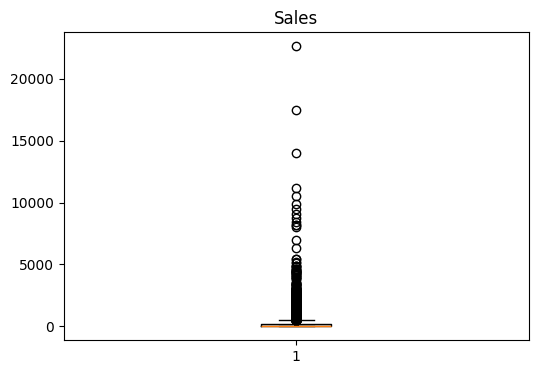

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.boxplot(df["Sales"])
plt.title("Sales")
plt.show()

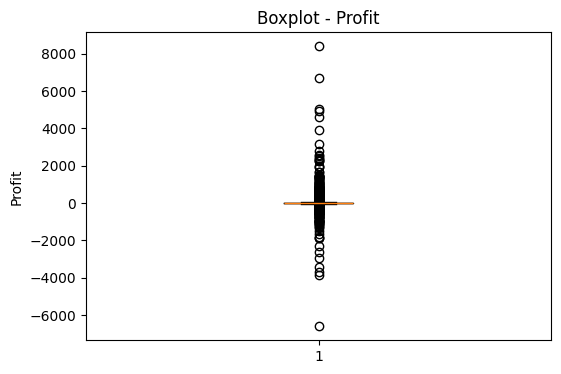

In [ ]:
plt.figure(figsize=(6,4))
plt.boxplot(df["Profit"])
plt.title("Boxplot - Profit")
plt.ylabel("Profit")
plt.show()

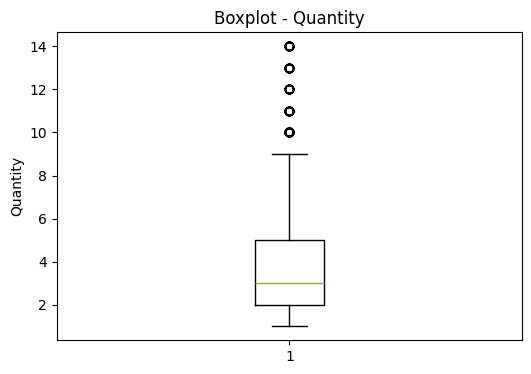

In [ ]:
plt.figure(figsize=(6,4))
plt.boxplot(df["Quantity"])
plt.title("Boxplot - Quantity")
plt.ylabel("Quantity")
plt.show()

AS 3 PERGUNTAS que devemos fazer quando estamos olhando para os outliers:


1. o valor é impossível?
ex: qntd = -8

2. O valor é um erro de digitação?
ex: preço = 99999999

3. o valor é raro, mas possível?



Pensar sempre no contexto de vendas e o que faz sentido nessa lógica!

ANÁLISE EXPLORATÓRIA DOS DADOS (EDA)


Levando em conta a situação que temos, definimos as seguintes questões:

Panorama geral

In [ ]:
df[["Sales","Profit","Quantity","Discount"]].describe()

,Sales,Profit,Quantity,Discount
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,28.656896,3.789574,0.156203
std,623.245101,234.260108,2.225110,0.206452
min,0.444000,-6599.978000,1.000000,0.000000
25%,17.280000,1.728750,2.000000,0.000000
50%,54.490000,8.666500,3.000000,0.200000
75%,209.940000,29.364000,5.000000,0.200000
max,22638.480000,8399.976000,14.000000,0.800000


### 5. Exploratory Data Analysis (EDA)

###BQ1: Qual categoria gera maior faturamento?

In [ ]:
#criar a variavel para agruopamento das vendas por categorias!

                       Sales
Category                    
Technology       836154.0330
Furniture        741999.7953
Office Supplies  719047.0320


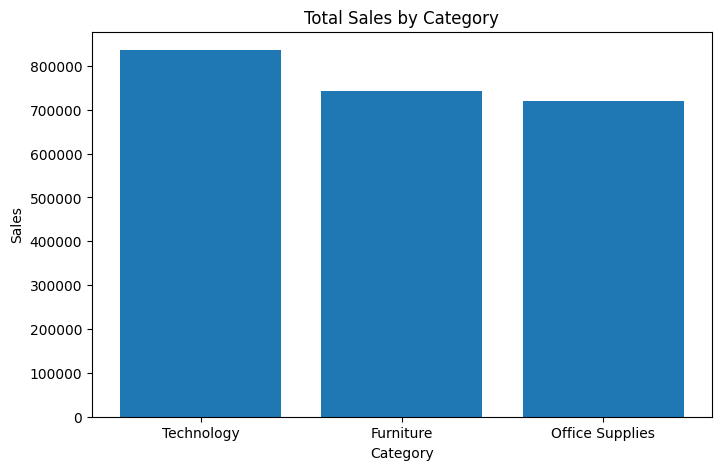

In [ ]:
sales_category = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(sales_category.to_frame())

# traçar gráfico para ilustrar o que achamos agr


plt.figure(figsize=(8,5))
plt.bar(sales_category.index, sales_category.values)


plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.show()

### Interpretation

Technology generated the highest total sales revenue, followed by Furniture and Office Supplies.

Although Office Supplies contains a larger variety of products, Technology contributes the greatest share of revenue, indicating that higher-value products have a significant impact on total sales.

### Business Insight

Technology is the leading revenue-generating category, making it a strategic area for the business.

This suggests that investments in product availability, marketing campaigns, and promotional efforts focused on Technology products could positively impact overall sales performance.

However, high revenue does not necessarily imply high profitability. Therefore, the next step is to analyze profit by category to determine whether Technology also delivers the greatest financial return.

###BQ2: Categoria com maior lucro?

                      Profit
Category                    
Technology       145454.9481
Office Supplies  122490.8008
Furniture         18451.2728


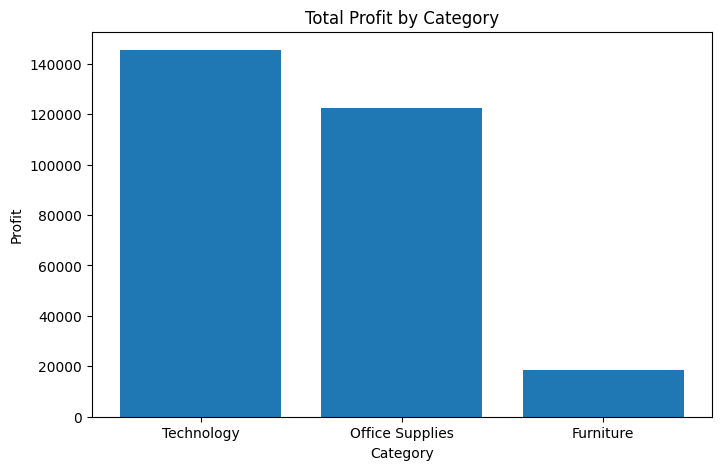

In [ ]:
profit_category = (
    df.groupby("Category")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

print(profit_category.to_frame())

# traçar gráfico para ilustrar o que achamos agr


plt.figure(figsize=(8,5))
plt.bar(profit_category.index, profit_category.values)


plt.title("Total Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.show()

### Interpretation

Technology generated the highest total profit among all product categories, followed by Office Supplies and Furniture.

Although Furniture ranked second in total sales, it generated the lowest total profit, while Office Supplies achieved higher profitability despite lower sales revenue.

### Business Insight

The comparison between sales and profit reveals that high revenue does not necessarily lead to high profitability.

Furniture generated strong sales performance but the lowest total profit, suggesting that this category may be affected by lower profit margins, higher operational costs, or aggressive discount strategies.

To better understand this behavior, the next step is to analyze profit margins, discount levels, and the performance of Furniture sub-categories.

### BQ3: Which sub-categories generate the highest sales and profit?

###For Sales

                    Sales
Sub-Category             
Phones        330007.0540
Chairs        328449.1030
Storage       223843.6080
Tables        206965.5320
Binders       203412.7330
Machines      189238.6310
Accessories   167380.3180
Copiers       149528.0300
Bookcases     114879.9963
Appliances    107532.1610
Furnishings    91705.1640
Paper          78479.2060
Supplies       46673.5380
Art            27118.7920
Envelopes      16476.4020
Labels         12486.3120
Fasteners       3024.2800


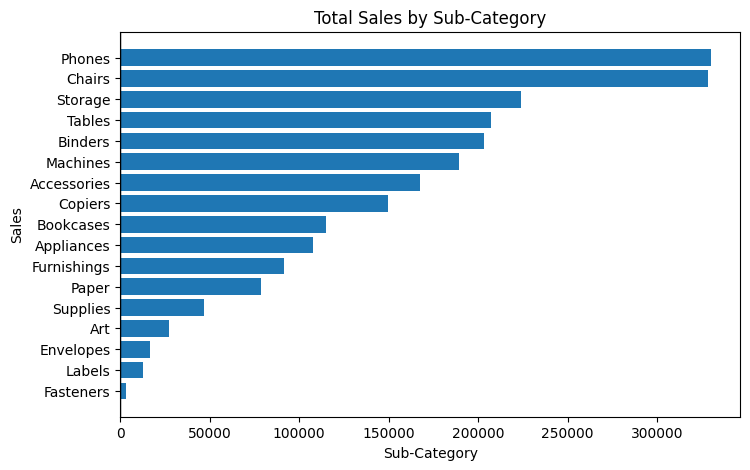

In [ ]:
sales_subcategory = (
    df.groupby("Sub-Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)



print(sales_subcategory.to_frame())

# traçar gráfico para ilustrar o que achamos agr


plt.figure(figsize=(8,5))

plt.barh(
    sales_subcategory.index,
    sales_subcategory.values
)


plt.title("Total Sales by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Sales")

plt.gca().invert_yaxis()

plt.axvline(x=0, color='black', linewidth=1)
plt.show()


###For profit


                  Profit
Sub-Category            
Copiers       55617.8249
Phones        44515.7306
Accessories   41936.6357
Paper         34053.5693
Binders       30221.7633
Chairs        26590.1663
Storage       21278.8264
Appliances    18138.0054
Furnishings   13059.1436
Envelopes      6964.1767
Art            6527.7870
Labels         5546.2540
Machines       3384.7569
Fasteners       949.5182
Supplies      -1189.0995
Bookcases     -3472.5560
Tables       -17725.4811


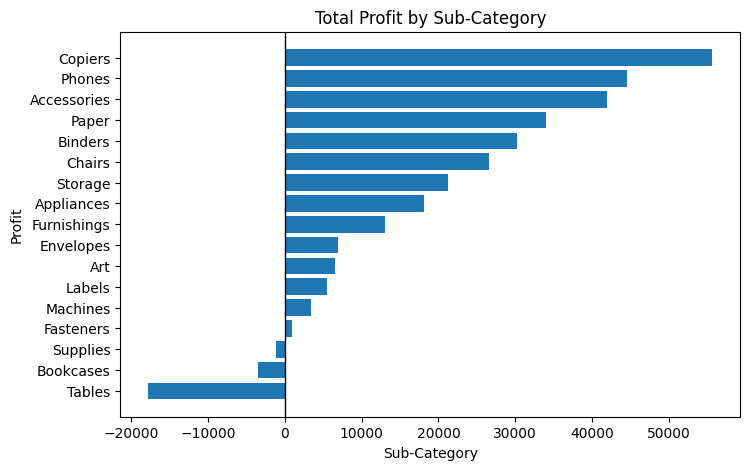

In [ ]:
profit_subcategory = (
    df.groupby("Sub-Category")["Profit"]
      .sum()
      .sort_values(ascending=False)
)



print(profit_subcategory.to_frame())

# traçar gráfico para ilustrar o que achamos agr


plt.figure(figsize=(8,5))

plt.barh(
    profit_subcategory.index,
    profit_subcategory.values
)


plt.title("Total Profit by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Profit")

plt.gca().invert_yaxis()

plt.axvline(x=0, color='black', linewidth=1)
plt.show()

### Interpretation

Sales and profit rankings differ considerably across sub-categories.

While Phones ranked first in total sales and second in total profit, Copiers generated the highest profit despite ranking only eighth in sales.

In contrast, Tables recorded one of the highest sales volumes but produced the largest financial loss among all sub-categories. Chairs and Storage also ranked highly in sales but generated comparatively lower profits.

These results indicate that strong sales performance does not always translate into high profitability.

### Business Insight

Comparing sales and profit reveals that revenue alone is not a sufficient measure of business performance.

Sub-categories such as Copiers create substantial value despite lower sales volumes, whereas Tables generate high revenue but operate at a significant loss.

This suggests that pricing strategies, discount policies, or cost structures should be further investigated, particularly for low-profit or loss-making sub-categories.

###BQ4: Does discount affect profitability?

In [ ]:
df["Discount"].unique()
# unique serve para separar os valores diferentes dentro da colunas

array([0.  , 0.45, 0.2 , 0.8 , 0.3 , 0.5 , 0.7 , 0.6 , 0.32, 0.1 , 0.4 ,
       0.15])

In [ ]:
#relacionar agora profit com o discount, criar variavel, mostrar tabela e criar gráficos.

discount_profit = (
    df.groupby("Discount")["Profit"]
      .mean()
      .sort_index()
)

display(discount_profit.to_frame())

,Profit
Discount,
0.00,66.900292
0.10,96.055074
0.15,27.288298
0.20,24.702572
0.30,-45.679636
0.32,-88.560656
0.40,-111.927429
0.45,-226.646464
0.50,-310.703456


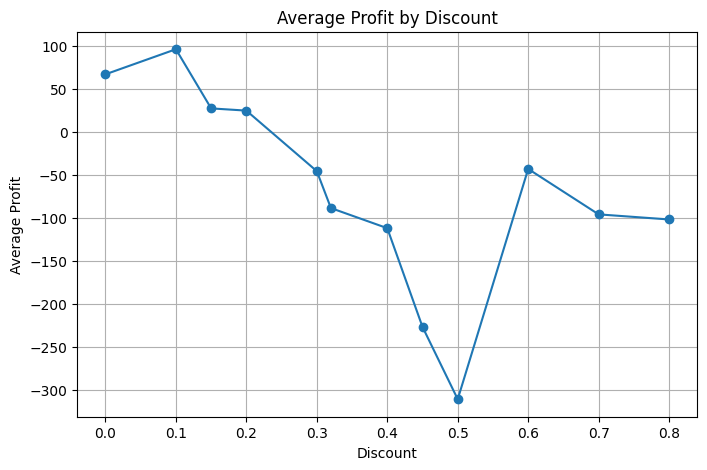

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    discount_profit.index,
    discount_profit.values,
    marker="o"
)

plt.title("Average Profit by Discount")
plt.xlabel("Discount")
plt.ylabel("Average Profit")

plt.grid(True)

plt.show()

In [ ]:
df["Discount"].value_counts().sort_index()

,count
Discount,
0.00,4798
0.10,94
0.15,52
0.20,3657
0.30,227
0.32,27
0.40,206
0.45,11
0.50,66


###Interpretation

The analysis is nonlinear and generally indicates negative relationship between discount leves and average profit. or the majority of transactions, maintain positive average profits. In contrast, discounts of 30% or more are consistently associated with negative average profits. Although the 10% discount level shows the highest average profit, this result is based on a relatively small number of orders and should therefore be interpreted with caution.

###Business Insight

The results suggest that aggressive discount strategies may significantly reduce profitability. Since the most common discount levels (0% and 20%) remain profitable, while higher discount levels frequently generate losses, the company should carefully evaluate the use of large discounts. Additionally, the exceptional performance observed at the 10% discount level warrants further investigation, as it may be driven by specific products, customer segments, or a limited sample size rather than representing a general business trend.


### BQ5: Which customer segment generates the highest sales and profit?


###For Sales

In [ ]:
sales_segment = (
    df.groupby("Segment")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

display(sales_segment.to_frame())

,Sales
Segment,
Consumer,1.161401e+06
Corporate,7.061464e+05
Home Office,4.296531e+05


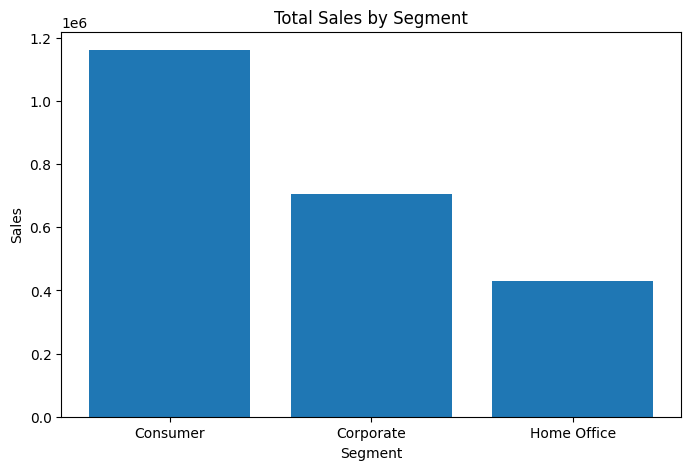

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    sales_segment.index,
    sales_segment.values
)

plt.title("Total Sales by Segment")
plt.xlabel("Segment")
plt.ylabel("Sales")

plt.show()

###For Profit

In [42]:
profit_segment = (
    df.groupby("Segment")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

display(profit_segment.to_frame())

,Profit
Segment,
Consumer,134119.2092
Corporate,91979.1340
Home Office,60298.6785


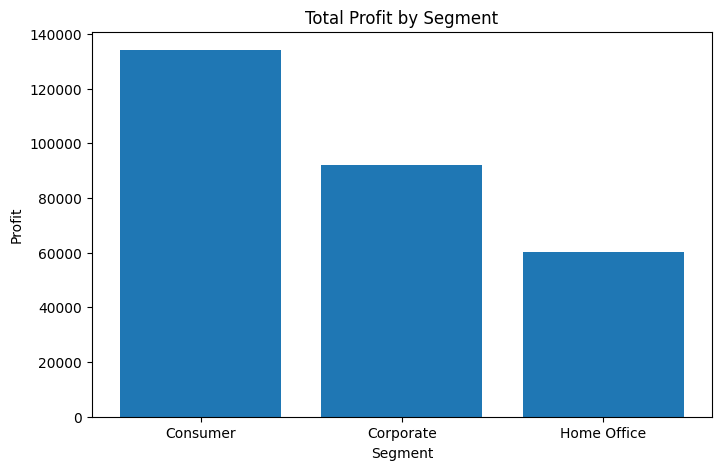

In [43]:
plt.figure(figsize=(8,5))

plt.bar(
    profit_segment.index,
    profit_segment.values
)

plt.title("Total Profit by Segment")
plt.xlabel("Segment")
plt.ylabel("Profit")

plt.show()

### Interpretation

The Consumer segment generated the highest total sales and total profit, followed by the Corporate segment and Home Office.

The ranking remained consistent across both sales and profit, indicating that the segment with the highest revenue also delivers the highest overall profitability.

No significant discrepancy was observed between sales performance and profit generation among the three customer segments.

### Business Insight

The Consumer segment is the company's primary revenue and profit driver, making it the most valuable customer segment from a business perspective.

Although the Corporate and Home Office segments contribute less to overall performance, they still represent meaningful sources of revenue and profit. The company may benefit from strengthening marketing and sales strategies targeted at these segments while maintaining its strong position in the Consumer market.

### BQ6: Which regions and states generate the highest sales and profit?

In [ ]:
df["Region"].unique()

# lembrar que o regio



sales_region = (
    df.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

display(sales_region.to_frame())


#seleção e ordem crescente


,Sales
Region,
West,725457.8245
East,678781.2400
Central,501239.8908
South,391721.9050


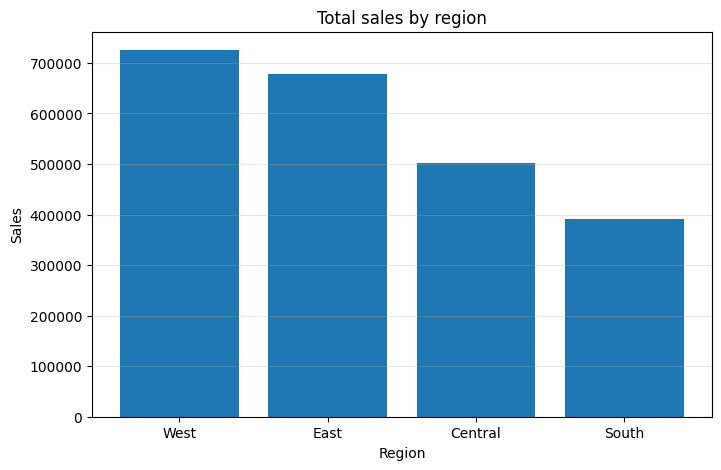

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    sales_region.index,
    sales_region.values
)

plt.title("Total sales by region")

plt.xlabel("Region")

plt.ylabel("Sales")

plt.grid(axis="y",alpha=0.3)

plt.show()

In [ ]:
profit_region = (
    df.groupby("Region")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

display(profit_region.to_frame())

,Profit
Region,
West,108418.4489
East,91522.7800
South,46749.4303
Central,39706.3625


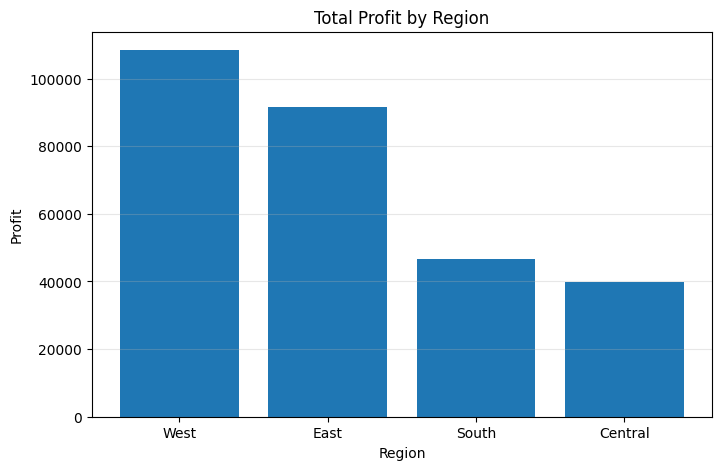

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    profit_region.index,
    profit_region.values
)

plt.title("Total Profit by Region")

plt.xlabel("Region")

plt.ylabel("Profit")

plt.grid(axis="y", alpha=0.3)

plt.show()

###Interpretation

West has the highest values both in profit and sales.


###Business Insight

It is interessant for others regions analyse the factors why the west regipn got the highest values. It suggests that maintaining market share in thois region should remain a strategic priority.

###State Context

In [ ]:
sales_state = (
    df.groupby("State")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

display(sales_state.to_frame())


,Sales
State,
California,457687.6315
New York,310876.2710
Texas,170188.0458
Washington,138641.2700
Pennsylvania,116511.9140
Florida,89473.7080
Illinois,80166.1010
Ohio,78258.1360
Michigan,76269.6140


In [ ]:
profit_state = (
    df.groupby("State")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

display(profit_state.to_frame())


,Profit
State,
California,76381.3871
New York,74038.5486
Washington,33402.6517
Michigan,24463.1876
Virginia,18597.9504
Indiana,18382.9363
Georgia,16250.0433
Kentucky,11199.6966
Minnesota,10823.1874


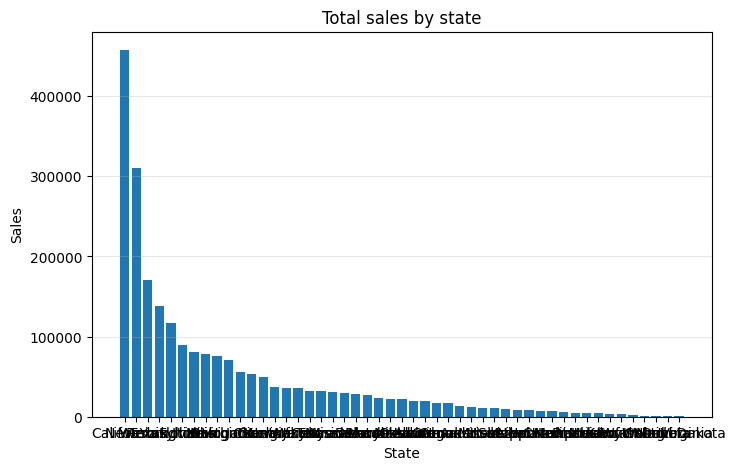

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    sales_state.index,
    sales_state.values
)

plt.title("Total sales by state")

plt.xlabel("State")

plt.ylabel("Sales")

plt.grid(axis="y",alpha=0.3)

plt.show()

How have sales and profits evolved over time?

In [7]:
df["Year_Month"] = df["Order Date"].dt.to_period("M")

###criando uma coluna Year-Month

In [8]:
df["Year_Month"] = df["Order Date"].dt.to_period("M")

In [12]:
profit_time = (
    df.groupby("Year_Month")["Profit"]
      .sum()
)


sales_time = (
    df.groupby("Year_Month")["Sales"]
      .sum()
)

In [14]:
sales_time.index = sales_time.index.astype(str)
profit_time.index = profit_time.index.astype(str)

In [15]:
###Criar o gráfico, utiliando as linhas ao invés de barras, para um melhor ajute visual.




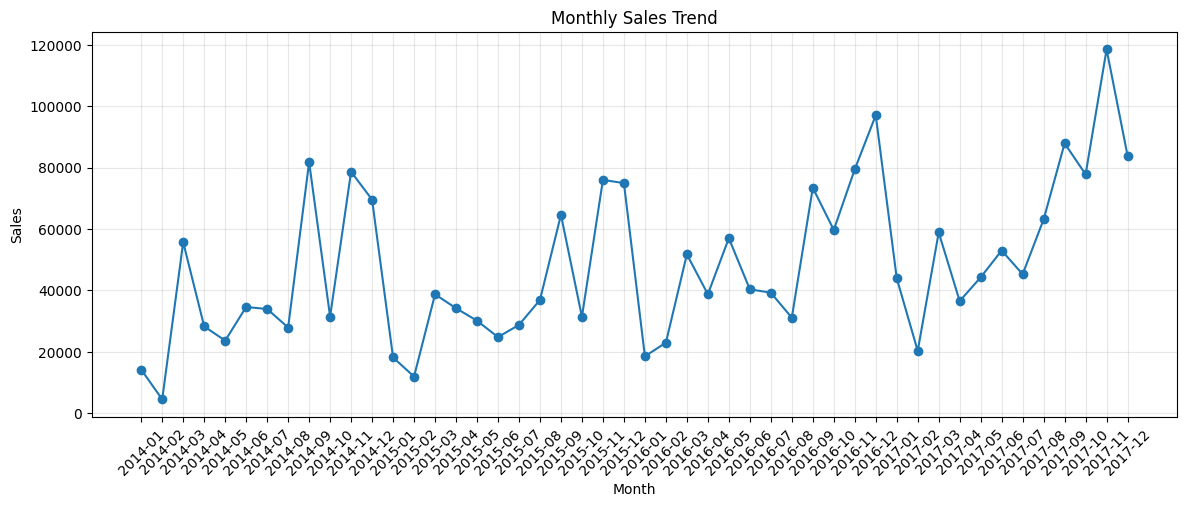

In [16]:
#SALES
plt.figure(figsize=(14,5))

plt.plot(
    sales_time.index,
    sales_time.values,
    marker="o"
)

plt.title("Monthly Sales Trend")

plt.xlabel("Month")

plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.show()

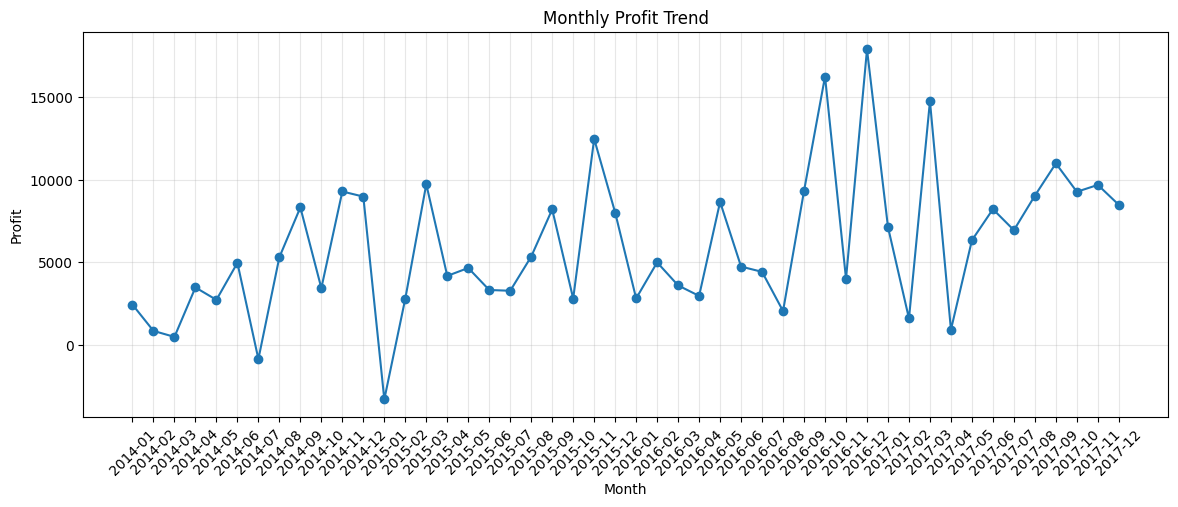

In [17]:
plt.figure(figsize=(14,5))

plt.plot(
    profit_time.index,
    profit_time.values,
    marker="o"
)

plt.title("Monthly Profit Trend")

plt.xlabel("Month")

plt.ylabel("Profit")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.show()

### Interpretation

Monthly sales fluctuated throughout the period, but an overall upward trend can be observed from 2014 to 2017.

Sales reached their highest levels during the second half of each year, particularly between September and November. The highest monthly sales were recorded in late 2017.

Monthly profit generally followed a similar pattern to sales, increasing over time despite some fluctuations. However, a few months experienced significantly lower profit or even losses, indicating that higher sales do not always translate into higher profitability.

### Business Insight

The results suggest a clear seasonal pattern, with stronger sales and profits occurring during the last quarter of the year. This indicates that demand increases during this period, making it an ideal time to reinforce inventory planning, marketing campaigns, and operational capacity.

Additionally, some months generated high sales but comparatively lower profit, suggesting that pricing strategies, product mix, or discount policies should be reviewed to maximize profitability during peak demand periods.

###Which shipping mode performs best?

In [ ]:
#O que estamos querendo responder é o SEGUINTE.

#Qual modalidade gera maior faturamento?
#Qual gera maior lucro?
#A mais utiizada também é a mais lucrativa?

In [18]:
#Sales by Shipping Mode

sales_shipmode = (
    df.groupby("Ship Mode")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

display(sales_shipmode.to_frame())


,Sales
Ship Mode,
Standard Class,1.358216e+06
Second Class,4.591936e+05
First Class,3.514284e+05
Same Day,1.283631e+05


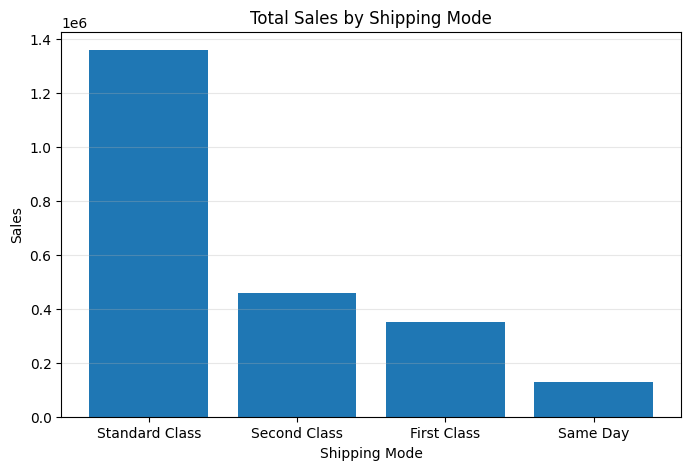

In [19]:
plt.figure(figsize=(8,5))

plt.bar(
    sales_shipmode.index,
    sales_shipmode.values
)

plt.title("Total Sales by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Sales")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [20]:
profit_shipmode = (
    df.groupby("Ship Mode")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

display(profit_shipmode.to_frame())

,Profit
Ship Mode,
Standard Class,164088.7875
Second Class,57446.6354
First Class,48969.8399
Same Day,15891.7589


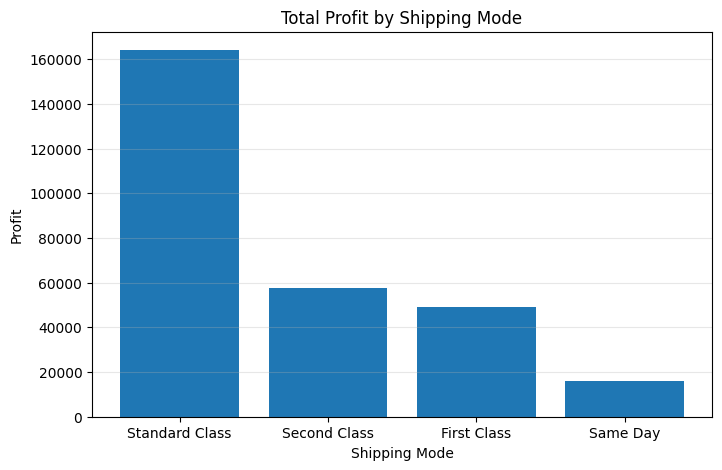

In [21]:
plt.figure(figsize=(8,5))

plt.bar(
    profit_shipmode.index,
    profit_shipmode.values
)

plt.title("Total Profit by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Profit")

plt.grid(axis="y", alpha=0.3)

plt.show()

### Interpretation

Standard Class generated the highest total sales and total profit by a considerable margin, followed by Second Class, First Class, and Same Day.

The ranking remained consistent across both sales and profit, indicating that the most frequently used shipping mode also contributes the most to the company's overall profitability.

### Business Insight

Standard Class is the company's primary shipping mode, driving both revenue and profitability. This suggests that maintaining the efficiency and reliability of this shipping option is essential for sustaining business performance.

Although premium shipping options such as First Class and Same Day contribute less to overall sales and profit, they may still play an important role in meeting specific customer needs and improving customer satisfaction.

 ### BQ9: Who are the most valuable customers based on sales and profit?

In [22]:
sales_customer = (
    df.groupby("Customer Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

display(sales_customer.to_frame())

,Sales
Customer Name,
Sean Miller,25043.050
Tamara Chand,19052.218
Raymond Buch,15117.339
Tom Ashbrook,14595.620
Adrian Barton,14473.571
Ken Lonsdale,14175.229
Sanjit Chand,14142.334
Hunter Lopez,12873.298
Sanjit Engle,12209.438


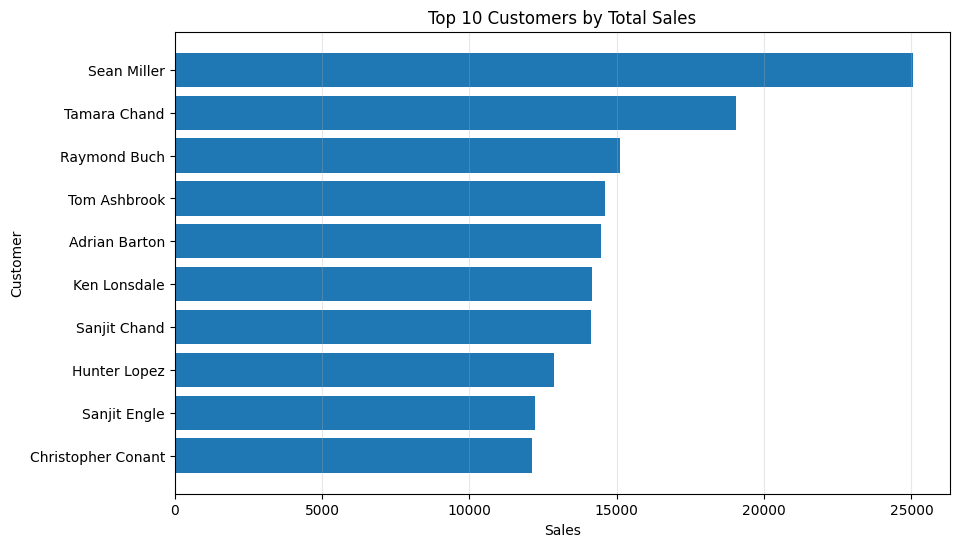

In [23]:
plt.figure(figsize=(10,6))

plt.barh(
    sales_customer.index,
    sales_customer.values
)

plt.title("Top 10 Customers by Total Sales")
plt.xlabel("Sales")
plt.ylabel("Customer")

plt.grid(axis="x", alpha=0.3)

plt.gca().invert_yaxis()

plt.show()

In [24]:
profit_customer = (
    df.groupby("Customer Name")["Profit"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

display(profit_customer.to_frame())

,Profit
Customer Name,
Tamara Chand,8981.3239
Raymond Buch,6976.0959
Sanjit Chand,5757.4119
Hunter Lopez,5622.4292
Adrian Barton,5444.8055
Tom Ashbrook,4703.7883
Christopher Martinez,3899.8904
Keith Dawkins,3038.6254
Andy Reiter,2884.6208


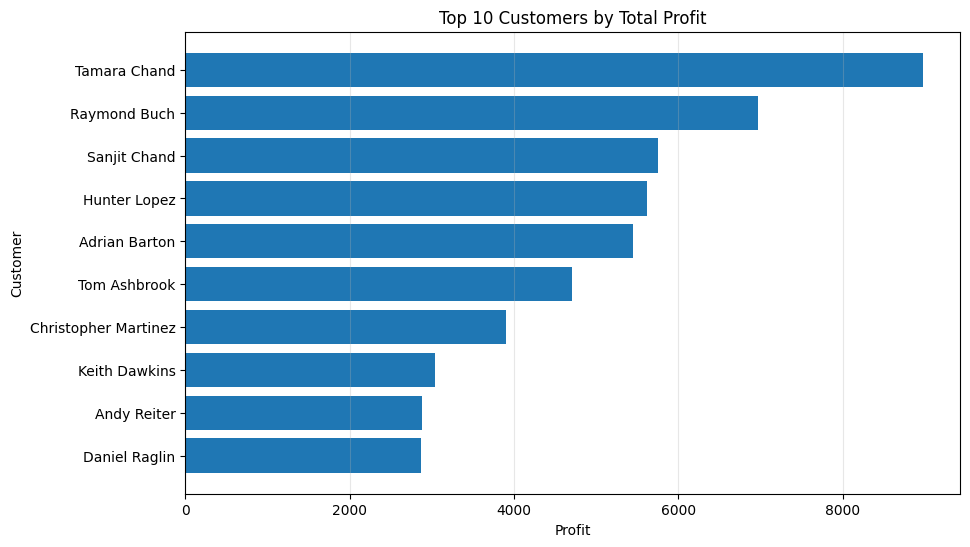

In [25]:
plt.figure(figsize=(10,6))

plt.barh(
    profit_customer.index,
    profit_customer.values
)

plt.title("Top 10 Customers by Total Profit")
plt.xlabel("Profit")
plt.ylabel("Customer")

plt.grid(axis="x", alpha=0.3)

plt.gca().invert_yaxis()

plt.show()

### Interpretation

The customers with the highest total sales are not exactly the same as those generating the highest total profit.

Sean Miller generated the highest total sales, while Tamara Chand generated the highest total profit. Several customers appear in both rankings, such as Raymond Buch, Adrian Barton, Tom Ashbrook, Hunter Lopez, and Sanjit Chand, indicating that they are consistently valuable to the business.

However, some customers rank highly in sales but do not appear among the most profitable customers, suggesting that higher revenue does not always translate into higher profitability.

### Business Insight

The analysis highlights the importance of evaluating customer performance using both sales and profit. Customers who generate high revenue but relatively low profit may be receiving larger discounts or purchasing lower-margin products.

On the other hand, customers who consistently rank among the top in both sales and profit represent strategic relationships and should be prioritized through customer retention initiatives and personalized business strategies.

### BQ10: Which products generate the highest sales and profit?

In [26]:
sales_product = (
    df.groupby("Product Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

display(sales_product.to_frame())

,Sales
Product Name,
Canon imageCLASS 2200 Advanced Copier,61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480
HON 5400 Series Task Chairs for Big and Tall,21870.576
GBC DocuBind TL300 Electric Binding System,19823.479
GBC Ibimaster 500 Manual ProClick Binding System,19024.500
Hewlett Packard LaserJet 3310 Copier,18839.686
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895
GBC DocuBind P400 Electric Binding System,17965.068


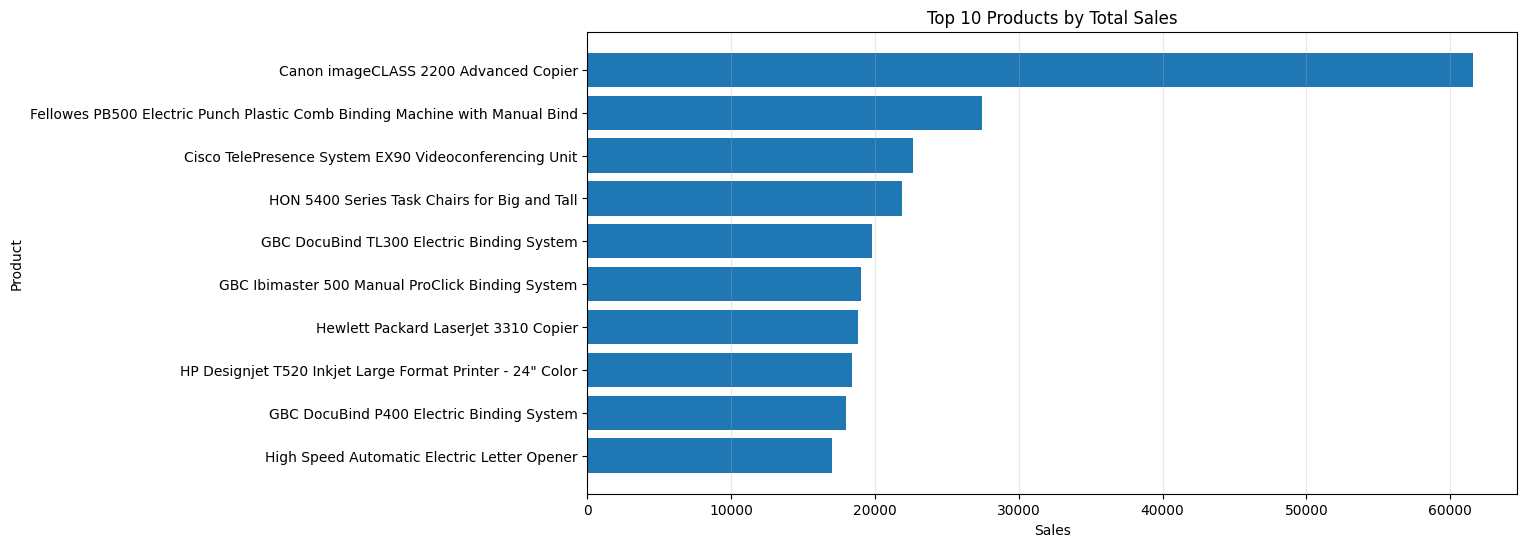

In [27]:
plt.figure(figsize=(12,6))

plt.barh(
    sales_product.index,
    sales_product.values
)

plt.title("Top 10 Products by Total Sales")
plt.xlabel("Sales")
plt.ylabel("Product")

plt.grid(axis="x", alpha=0.3)

plt.gca().invert_yaxis()

plt.show()

In [28]:
profit_product = (
    df.groupby("Product Name")["Profit"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

display(profit_product.to_frame())

,Profit
Product Name,
Canon imageCLASS 2200 Advanced Copier,25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,7753.0390
Hewlett Packard LaserJet 3310 Copier,6983.8836
Canon PC1060 Personal Laser Copier,4570.9347
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",4094.9766
Ativa V4110MDD Micro-Cut Shredder,3772.9461
"3D Systems Cube Printer, 2nd Generation, Magenta",3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System,3696.2820
Ibico EPK-21 Electric Binding System,3345.2823


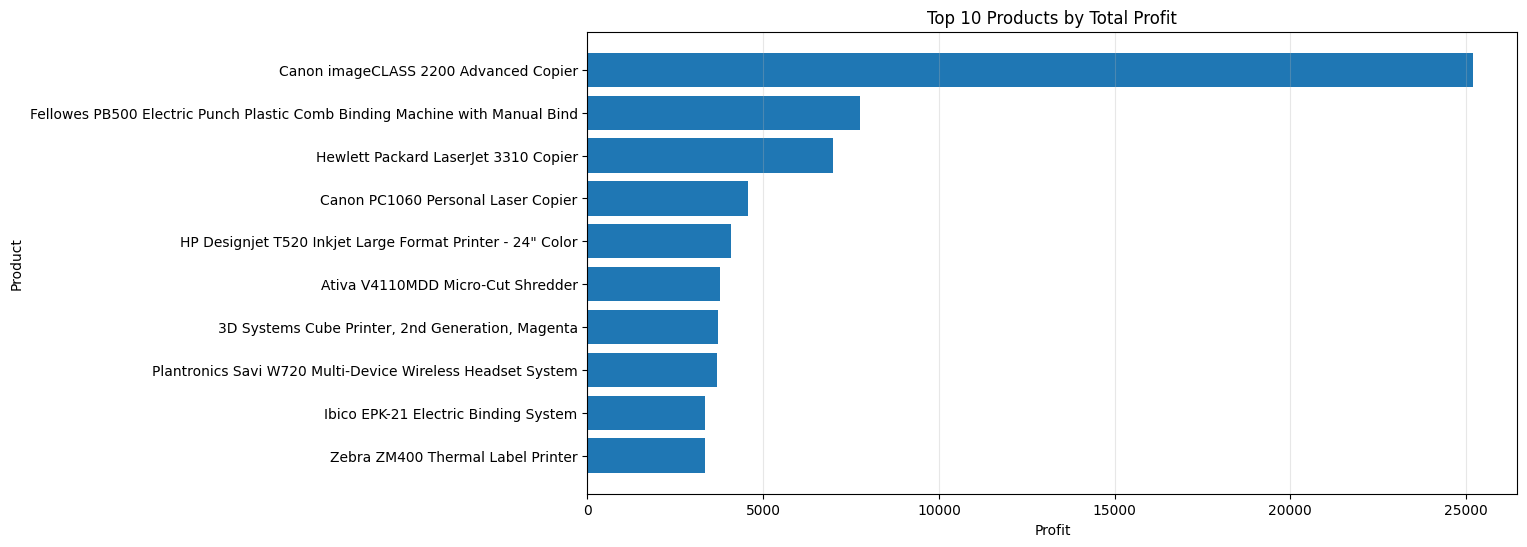

In [29]:
plt.figure(figsize=(12,6))

plt.barh(
    profit_product.index,
    profit_product.values
)

plt.title("Top 10 Products by Total Profit")
plt.xlabel("Profit")
plt.ylabel("Product")

plt.grid(axis="x", alpha=0.3)

plt.gca().invert_yaxis()

plt.show()

### Interpretation

The Canon imageCLASS 2200 Advanced Copier ranked first in both total sales and total profit, making it the best-performing product in the dataset.

However, the remaining rankings differ considerably. Several products that appear among the top-selling items do not rank among the most profitable ones, while some highly profitable products are absent from the top sales ranking.

These differences indicate that strong sales performance does not necessarily translate into higher profitability at the product level.

### Business Insight

The analysis reinforces the importance of evaluating products based on both revenue and profitability. While high-selling products contribute significantly to total revenue, highly profitable products may generate greater business value even with lower sales volumes.

The company should continue investing in products that consistently perform well in both sales and profit, while reviewing pricing, discount strategies, and product costs for high-selling products with comparatively lower profitability.

# 6. Executive Summary

After conducting the exploratory data analysis, several important business insights were identified:

### 1. Technology is the company's best-performing category.

Technology generated both the highest total sales and the highest total profit, confirming its strategic importance to the business.

---

### 2. High sales do not always lead to high profitability.

Throughout the analysis, several products and sub-categories generated strong sales but relatively low or even negative profit. The Tables sub-category is the clearest example, producing high revenue while generating losses.

---

### 3. Discounts have a significant impact on profitability.

Orders with discounts above approximately 30% were associated with negative average profits, suggesting that aggressive discount policies reduce profitability.

---

### 4. Consumer is the company's most valuable customer segment.

The Consumer segment ranked first in both total sales and total profit, making it the primary contributor to the company's financial performance.

---

### 5. The West region represents the strongest market.

The West region consistently generated the highest sales and profit, indicating a strong customer base and market presence.

---

### 6. Sales and profit increased over time.

The monthly analysis revealed an overall upward trend between 2014 and 2017, with recurring peaks during the final months of each year, suggesting seasonal demand.

---

### 7. Customer value should be evaluated using both sales and profit.

Several customers generated high sales without ranking among the most profitable ones. This reinforces the importance of considering profitability in customer analysis.

---

### 8. Copiers are highly profitable products.

The Canon imageCLASS 2200 Advanced Copier ranked first in both sales and profit, reinforcing the strong performance of the Copiers sub-category.

# 7. Business Recommendations

Based on the findings, the following recommendations could help improve business performance:

### Review discount policies

Since higher discount levels were associated with lower profitability, the company should evaluate its pricing strategy and limit excessive discounts whenever possible.

---

### Prioritize high-margin products

Products and sub-categories with consistently high profitability, especially Copiers and Technology products, should receive additional marketing investment and inventory planning.

---

### Investigate underperforming products

Products with high sales but low or negative profit, such as those within the Tables sub-category, should be analyzed to identify pricing, cost, or discount issues.

---

### Strengthen customer retention

Highly profitable customers should be prioritized through loyalty programs and personalized business strategies.

---

### Prepare for seasonal demand

Since sales consistently increase during the last quarter of the year, inventory management and marketing campaigns should be planned in advance.

---

### Expand successful regional strategies

Business practices contributing to the strong performance of the West region could be replicated in lower-performing regions to stimulate growth.

# 8. Conclusion

This project explored sales data from a retail company through a complete Exploratory Data Analysis (EDA) process using Python, Pandas, and Matplotlib.

The analysis identified key business patterns related to product performance, customer behavior, regional sales, discount strategies, and profitability.

Overall, the results demonstrate that business decisions should consider not only revenue but also profitability, since higher sales do not always generate higher profits.

This project also reinforced the importance of transforming raw data into actionable business insights, supporting more informed strategic decisions.

Finally, the analysis demonstrates practical skills in data cleaning, exploratory data analysis, data visualization, and business-oriented problem solving, which are essential competencies for Data Analysts.

### 9. Tools Used

Python

Pandas

Matplotlib

NumPy

Jupyter Notebook

### 10. Skills Demonstred

Data Cleaning

EDA

Data Visualization

Business Analysis

Business Insight Generation

Pandas

Python